# Detection: Intraseasonal OLR Anomaly Analysis

This notebook computes 20-80 day band-pass filtered OLR anomalies for BSISO/MJO detection.

**Methodology:**
1. Remove time mean from the data
2. Apply 20-80 day band-pass filter
3. Visualize the intraseasonal anomalies

In [62]:
# Import required libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import subprocess
import os
import tempfile

## 1. Define Processing Functions

In [63]:
def bandpass_filter(data, low_freq, high_freq, window=201):
    """Apply band-pass filter using Hamming window (operates on 1-D array)."""
    filt = signal.firwin(window, [low_freq, high_freq],
                         pass_zero=False, window='hamming', fs=1.0)
    return signal.filtfilt(filt, 1.0, data, axis=0, padtype='even')


def remove_anomalies(data):
    """Remove climatological annual cycle (day-of-year mean) from data."""
    climatology = data.groupby('time.dayofyear').mean('time')
    return data.groupby('time.dayofyear') - climatology


def apply_intraseasonal_filter(data, low_period=80, high_period=30,
                                use_dask=False, n_workers=4, chunks=None):
    """
    Apply intraseasonal band-pass filter (Hamming FIR) to anomaly data.

    Parameters
    ----------
    data : xr.DataArray
        Input anomaly data, shape (time, lat, lon).
    low_period : int, optional
        Upper period bound in days. Default 80.
    high_period : int, optional
        Lower period bound in days. Default 30.
    use_dask : bool, optional
        If True, use a dask.distributed LocalCluster for parallel computation.
    n_workers : int, optional
        Number of dask worker processes. Default 4.
    chunks : dict or None, optional
        Chunk sizes. Defaults to ``{'time': -1, 'lat': 10, 'lon': -1}``.

    Returns
    -------
    filtered : xr.DataArray
        Band-pass filtered data.
    """
    import time as _time

    low_freq  = 1.0 / low_period
    high_freq = 1.0 / high_period
    tag = '[dask]' if use_dask else '[serial]'
    print(f"Applying Hamming (FIR) {high_period}-{low_period} day  {tag}")
    print(f"  Frequency range: {low_freq:.5f} to {high_freq:.5f} cycles/day")

    if use_dask:
        from dask.distributed import Client, LocalCluster

        if chunks is None:
            chunks = {'time': -1, 'lat': 10, 'lon': -1}

        data_chunked = data.chunk(chunks)
        cluster = LocalCluster(n_workers=n_workers, threads_per_worker=1,
                               silence_logs=40)
        client  = Client(cluster, timeout='30s')
        try:
            t0 = _time.perf_counter()
            filtered = xr.apply_ufunc(
                bandpass_filter,
                data_chunked,
                low_freq, high_freq,
                input_core_dims=[['time'], [], []],
                output_core_dims=[['time']],
                vectorize=True,
                dask='parallelized',
                output_dtypes=[float],
            )
            filtered = filtered.compute()
            elapsed = _time.perf_counter() - t0
        finally:
            client.close()
            cluster.close()
    else:
        t0 = _time.perf_counter()
        filtered = xr.apply_ufunc(
            bandpass_filter,
            data,
            low_freq, high_freq,
            input_core_dims=[['time'], [], []],
            output_core_dims=[['time']],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float],
        )
        elapsed = _time.perf_counter() - t0

    print(f"  Completed in {elapsed:.3f} s")

    filtered = filtered.assign_coords(data.coords)
    filtered.attrs = data.attrs.copy()
    filtered.attrs['long_name'] = f'{high_period}-{low_period} day filtered anomaly'
    filtered.name = f'{data.name}_{high_period}_{low_period}_day'
    return filtered


def plot_comparison(original, filtered, lat=0, lon=90, time_slice='1990'):
    """Plot comparison between original and filtered anomalies."""
    orig_ts = original.sel(lat=lat, lon=lon, method='nearest')
    filt_ts = filtered.sel(lat=lat, lon=lon, method='nearest')

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    axes[0].plot(orig_ts.sel(time=time_slice).time,
                 orig_ts.sel(time=time_slice), 'b-', linewidth=0.8)
    axes[0].set_ylabel('OLR Anomaly (W/m²)', fontsize=11)
    axes[0].set_title(f'Original Anomaly at ({lat}°N, {lon}°E)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)

    axes[1].plot(filt_ts.sel(time=time_slice).time,
                 filt_ts.sel(time=time_slice), 'r-', linewidth=1.2)
    axes[1].set_ylabel('OLR Anomaly (W/m²)', fontsize=11)
    axes[1].set_xlabel('Time', fontsize=11)
    axes[1].set_title(f'{filtered.attrs.get("long_name","Filtered")} at ({lat}°N, {lon}°E)',
                      fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    print(f"Original anomaly range: {float(orig_ts.min()):.2f} to {float(orig_ts.max()):.2f} W/m²")
    print(f"Filtered anomaly range: {float(filt_ts.min()):.2f} to {float(filt_ts.max()):.2f} W/m²")


In [64]:
def lanczos_filter(data, low_period=80, high_period=30, window=121):
    """
    Lanczos filter - commonly used in climate science.
    
    Parameters:
    -----------
    data : array-like
        Input time series data
    low_period : int
        Lower period bound in days
    high_period : int
        Upper period bound in days
    window : int
        Window length (must be odd)
        
    Returns:
    --------
    filtered_data : array-like
        Filtered time series
    """
    from scipy import signal
    
    low_freq = 1.0 / low_period
    high_freq = 1.0 / high_period
    filt = signal.firwin(window, [low_freq, high_freq], 
                         pass_zero=False, window='boxcar', fs=1.0)
    filtered = signal.filtfilt(filt, 1.0, data, axis=0, padtype='even')
    return filtered


def butterworth_filter(data, low_period=80, high_period=30, order=5):
    """
    Butterworth filter with higher order for sharper cutoff.
    
    Parameters:
    -----------
    data : array-like
        Input time series data
    low_period : int
        Lower period bound in days
    high_period : int
        Upper period bound in days
    order : int
        Filter order (higher = sharper, default=5)
        
    Returns:
    --------
    filtered_data : array-like
        Filtered time series
    """
    from scipy import signal
    
    low_freq = 2.0 / low_period
    high_freq = 2.0 / high_period
    b, a = signal.butter(order, [low_freq, high_freq], 'bandpass')
    filtered = signal.filtfilt(b, a, data, axis=0, padtype='even')
    return filtered


def chebyshev_filter(data, low_period=80, high_period=30, order=5, ripple=0.5):
    """
    Chebyshev Type I filter - sharper transition than Butterworth.
    
    Parameters:
    -----------
    data : array-like
        Input time series data
    low_period : int
        Lower period bound in days
    high_period : int
        Upper period bound in days
    order : int
        Filter order
    ripple : float
        Maximum ripple in passband (dB)
        
    Returns:
    --------
    filtered_data : array-like
        Filtered time series
    """
    from scipy import signal
    
    low_freq = 2.0 / low_period
    high_freq = 2.0 / high_period
    b, a = signal.cheby1(order, ripple, [low_freq, high_freq], 'bandpass')
    filtered = signal.filtfilt(b, a, data, axis=0, padtype='even')
    return filtered


def apply_filter_to_data(data, filter_func, filter_name, use_dask=False,
                          n_workers=4, chunks=None, **kwargs):
    """
    Apply a filter function to xarray data, optionally accelerated with dask.

    Parameters
    ----------
    data : xr.DataArray
        Input data with dimensions (time, lat, lon).
    filter_func : callable
        Filter function that operates on a 1-D array along axis=0.
    filter_name : str
        Human-readable name for progress printing and output naming.
    use_dask : bool, optional
        If True, chunk `data` along (lat, lon) and use a
        dask.distributed LocalCluster for parallel computation.
        Default False (single-threaded xr.apply_ufunc).
    n_workers : int, optional
        Number of dask worker processes (only used when use_dask=True).
        Default 4.
    chunks : dict or None, optional
        Chunk sizes passed to ``data.chunk()``.  When None and
        use_dask=True a sensible default is chosen automatically
        (lat=10, lon=144 – full longitude strips).
    **kwargs
        Extra keyword arguments forwarded to ``filter_func``.

    Returns
    -------
    filtered : xr.DataArray
        Filtered data with same shape, coordinates, and attributes as input.
    """
    import time as _time

    print(f"Applying {filter_name}{'  [dask]' if use_dask else '  [serial]'}...")

    if use_dask:
        import dask
        import dask.array as da
        from dask.distributed import Client, LocalCluster

        if chunks is None:
            chunks = {'time': -1, 'lat': 10, 'lon': -1}

        data_chunked = data.chunk(chunks)

        cluster = LocalCluster(n_workers=n_workers, threads_per_worker=1,
                               silence_logs=40)
        client  = Client(cluster, timeout='30s')
        try:
            t0 = _time.perf_counter()
            filtered = xr.apply_ufunc(
                filter_func,
                data_chunked,
                input_core_dims=[['time']],
                output_core_dims=[['time']],
                vectorize=True,
                dask='parallelized',
                output_dtypes=[float],
                kwargs=kwargs,
            )
            filtered = filtered.compute()   # trigger parallel execution
            elapsed = _time.perf_counter() - t0
        finally:
            client.close()
            cluster.close()
    else:
        t0 = _time.perf_counter()
        filtered = xr.apply_ufunc(
            filter_func,
            data,
            input_core_dims=[['time']],
            output_core_dims=[['time']],
            vectorize=True,
            dask='parallelized',
            output_dtypes=[float],
            kwargs=kwargs,
        )
        elapsed = _time.perf_counter() - t0

    print(f"  Completed in {elapsed:.3f} s")

    filtered = filtered.assign_coords(data.coords)
    filtered.attrs = data.attrs.copy()
    filtered.attrs['long_name'] = f'{filter_name} filtered anomaly'
    filtered.name = f'{data.name}_{filter_name.replace(" ", "_").lower()}'
    return filtered


In [65]:
def geocat_fourier_bandpass(data, low_period=80, high_period=20,
                             use_dask=False, n_workers=4, chunks=None):
    """
    Apply band-pass filter using geocat.comp.fourier_band_pass (frequency-domain).

    Performs an ideal rectangular band-pass in the Fourier domain, retaining
    only frequency components with periods in [high_period, low_period] days.

    Parameters
    ----------
    data : xr.DataArray
        Input anomaly data, shape (time, lat, lon).
    low_period : int, optional
        Upper period bound in days (low-frequency cutoff). Default 80.
    high_period : int, optional
        Lower period bound in days (high-frequency cutoff). Default 20.
    use_dask : bool, optional
        If True, chunk data along (lat, lon) and compute in parallel via
        a dask.distributed LocalCluster. Default False.
    n_workers : int, optional
        Number of dask worker processes (only used when use_dask=True).
    chunks : dict or None, optional
        Chunk sizes for ``data.chunk()``. Defaults to
        ``{'time': -1, 'lat': 10, 'lon': -1}`` when use_dask=True.

    Returns
    -------
    filtered : xr.DataArray
        Band-pass filtered data with same shape and coordinates as input.

    Notes
    -----
    - Sampling frequency is assumed to be 1 cycle/day (daily data).
    - Ideal rectangular cutoff → perfectly sharp edges but may introduce
      Gibbs ringing near the start/end of the time series.
    """
    from geocat.comp.fourier_filters import fourier_band_pass
    import time as _time

    fs               = 1.0
    cutoff_freq_low  = 1.0 / low_period
    cutoff_freq_high = 1.0 / high_period

    tag = '[dask]' if use_dask else '[serial]'
    print(f"Applying geocat.comp.fourier_band_pass ({high_period}–{low_period} day)  {tag}")
    print(f"  cutoff_frequency_low  = 1/{low_period}  = {cutoff_freq_low:.5f} cycle/day")
    print(f"  cutoff_frequency_high = 1/{high_period} = {cutoff_freq_high:.5f} cycle/day")

    if use_dask:
        from dask.distributed import Client, LocalCluster

        if chunks is None:
            chunks = {'time': -1, 'lat': 10, 'lon': -1}

        # fourier_band_pass works on whole time axis → keep time un-chunked
        data_chunked = data.chunk(chunks)

        cluster = LocalCluster(n_workers=n_workers, threads_per_worker=1,
                               silence_logs=40)
        client  = Client(cluster, timeout='30s')
        try:
            t0 = _time.perf_counter()
            filtered = xr.apply_ufunc(
                lambda arr: fourier_band_pass(
                    arr, frequency=fs,
                    cutoff_frequency_low=cutoff_freq_low,
                    cutoff_frequency_high=cutoff_freq_high,
                    time_axis=0,
                ),
                data_chunked,
                input_core_dims=[['time']],
                output_core_dims=[['time']],
                vectorize=False,          # fourier_band_pass handles all dims
                dask='parallelized',
                output_dtypes=[float],
            )
            filtered = filtered.compute()
            elapsed = _time.perf_counter() - t0
        finally:
            client.close()
            cluster.close()
    else:
        t0 = _time.perf_counter()
        filtered = fourier_band_pass(
            data,
            frequency=fs,
            cutoff_frequency_low=cutoff_freq_low,
            cutoff_frequency_high=cutoff_freq_high,
            time_axis=0,
        )
        elapsed = _time.perf_counter() - t0

    print(f"  Completed in {elapsed:.3f} s")

    filtered = filtered.assign_coords(data.coords)
    filtered.attrs = data.attrs.copy()
    filtered.attrs['long_name'] = (
        f'{high_period}-{low_period} day fourier_band_pass (geocat)'
    )
    filtered.name = 'olr_anomaly_geocat_fourier'
    return filtered


In [66]:
def compare_filters(python_filtered, cdo_filtered, lat=0, lon=90, time_slice='1990'):
    """
    Compare Python and CDO filter results.
    
    Parameters:
    -----------
    python_filtered : xr.DataArray
        Python filtered data
    cdo_filtered : xr.DataArray
        CDO filtered data
    lat : float, optional
        Latitude for time series extraction (default=0)
    lon : float, optional
        Longitude for time series extraction (default=90)
    time_slice : str, optional
        Year or time range to plot (default='1990')
    """
    # Extract time series
    py_ts = python_filtered.sel(lat=lat, lon=lon, method='nearest')
    cdo_ts = cdo_filtered.sel(lat=lat, lon=lon, method='nearest')
    
    # Create comparison figure
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # Python filter result
    axes[0].plot(py_ts.sel(time=time_slice).time, 
                 py_ts.sel(time=time_slice), 'b-', linewidth=1.0, label='Python')
    axes[0].set_ylabel('OLR Anomaly (W/m²)', fontsize=11)
    axes[0].set_title(f'Python Filter Result at ({lat}°N, {lon}°E)', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    axes[0].legend()
    
    # CDO filter result
    axes[1].plot(cdo_ts.sel(time=time_slice).time, 
                 cdo_ts.sel(time=time_slice), 'r-', linewidth=1.0, label='CDO')
    axes[1].set_ylabel('OLR Anomaly (W/m²)', fontsize=11)
    axes[1].set_title(f'CDO Filter Result at ({lat}°N, {lon}°E)', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    axes[1].legend()
    
    # Difference
    diff = py_ts - cdo_ts
    axes[2].plot(diff.sel(time=time_slice).time, 
                 diff.sel(time=time_slice), 'g-', linewidth=1.0, label='Python - CDO')
    axes[2].set_ylabel('Difference (W/m²)', fontsize=11)
    axes[2].set_xlabel('Time', fontsize=11)
    axes[2].set_title(f'Difference (Python - CDO) at ({lat}°N, {lon}°E)', fontsize=12)
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    axes[2].legend()
    axes[2].set_ylim(-50, 50)  # Set y-limits for difference plot
    axes[1].set_ylim(-50, 50)  # Set y-limits for difference plot
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*60}")
    print("Comparison Statistics:")
    print(f"{'='*60}")
    print(f"Python filter range: {float(py_ts.min()):.2f} to {float(py_ts.max()):.2f} W/m²")
    print(f"CDO filter range:    {float(cdo_ts.min()):.2f} to {float(cdo_ts.max()):.2f} W/m²")
    print(f"Mean difference:     {float(diff.mean()):.4f} W/m²")
    print(f"RMSE:                {float(np.sqrt((diff**2).mean())):.4f} W/m²")
    print(f"Max abs difference:  {float(np.abs(diff).max()):.4f} W/m²")
    print(f"Correlation:         {float(xr.corr(py_ts, cdo_ts)):.6f}")
    print(f"{'='*60}")

In [67]:
def compare_three_filters(original, firwin_filtered, butter_filtered, cdo_filtered, 
                          lat=0, lon=90, time_slice='1990'):
    """
    Compare three different filter methods in one figure.
    
    Parameters:
    -----------
    original : xr.DataArray
        Original anomaly data
    firwin_filtered : xr.DataArray
        FIR window (Hamming) filtered data
    butter_filtered : xr.DataArray
        Butterworth filtered data
    cdo_filtered : xr.DataArray
        CDO filtered data
    lat : float, optional
        Latitude for time series extraction (default=0)
    lon : float, optional
        Longitude for time series extraction (default=90)
    time_slice : str, optional
        Year or time range to plot (default='1990')
    """
    # Extract time series at specified location
    orig_ts = original.sel(lat=lat, lon=lon, method='nearest')
    fir_ts = firwin_filtered.sel(lat=lat, lon=lon, method='nearest')
    butter_ts = butter_filtered.sel(lat=lat, lon=lon, method='nearest')
    cdo_ts = cdo_filtered.sel(lat=lat, lon=lon, method='nearest')
    
    # Convert CDO time to standard datetime64 for alignment
    # CDO uses noleap calendar, convert to pandas datetime for comparison
    import pandas as pd
    import cftime
    
    # Convert cftime to pandas datetime
    if hasattr(cdo_ts.time.values[0], 'calendar'):
        # CDO uses cftime, convert to pandas datetime
        cdo_times_pd = pd.to_datetime([pd.Timestamp(t.year, t.month, t.day) 
                                       for t in cdo_ts.time.values])
        cdo_ts['time'] = cdo_times_pd
    
    # Now align using the converted times
    # Find common time range
    common_time = np.intersect1d(fir_ts.time.values, cdo_ts.time.values)
    
    # Select common time period
    fir_ts = fir_ts.sel(time=common_time)
    butter_ts = butter_ts.sel(time=common_time)
    cdo_ts = cdo_ts.sel(time=common_time)
    orig_ts = orig_ts.sel(time=common_time)
    
    # Create comparison figure
    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    
    # Original anomaly
    axes[0].plot(orig_ts.sel(time=time_slice).time, 
                 orig_ts.sel(time=time_slice), 'gray', linewidth=0.6, alpha=0.7)
    axes[0].set_ylabel('OLR Anomaly\n(W/m²)', fontsize=11)
    axes[0].set_title(f'Original Anomaly at ({lat}°N, {lon}°E)', fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    axes[0].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    # All three filters overlaid
    axes[1].plot(fir_ts.sel(time=time_slice).time, 
                 fir_ts.sel(time=time_slice), 'b-', linewidth=1.5, label='FIR (Hamming)', alpha=0.8)
    axes[1].plot(butter_ts.sel(time=time_slice).time, 
                 butter_ts.sel(time=time_slice), 'r-', linewidth=1.5, label='Butterworth', alpha=0.8)
    axes[1].plot(cdo_ts.sel(time=time_slice).time, 
                 cdo_ts.sel(time=time_slice), 'g-', linewidth=1.5, label='CDO', alpha=0.8)
    axes[1].set_ylabel('OLR Anomaly\n(W/m²)', fontsize=11)
    axes[1].set_title('Comparison of Three Filter Methods', fontsize=12, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    axes[1].legend(loc='upper right', fontsize=10, framealpha=0.9)
    axes[1].set_ylim(-80, 80)
    
    # Differences: FIR vs CDO
    diff_fir_cdo = fir_ts - cdo_ts
    axes[2].plot(diff_fir_cdo.sel(time=time_slice).time, 
                 diff_fir_cdo.sel(time=time_slice), 'b-', linewidth=1.0, label='FIR - CDO')
    axes[2].set_ylabel('Difference\n(W/m²)', fontsize=11)
    axes[2].set_title('Differences Between Filter Methods', fontsize=12, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    axes[2].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    axes[2].legend(loc='upper right', fontsize=10)
    axes[2].set_ylim(-50, 50)
    
    # Differences: Butterworth vs CDO
    diff_butter_cdo = butter_ts - cdo_ts
    axes[3].plot(diff_butter_cdo.sel(time=time_slice).time, 
                 diff_butter_cdo.sel(time=time_slice), 'r-', linewidth=1.0, label='Butterworth - CDO')
    axes[3].set_ylabel('Difference\n(W/m²)', fontsize=11)
    axes[3].set_xlabel('Time', fontsize=11)
    axes[3].grid(True, alpha=0.3)
    axes[3].axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    axes[3].legend(loc='upper right', fontsize=10)
    axes[3].set_ylim(-50, 50)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{'='*80}")
    print(f"Three-Method Comparison Statistics at ({lat}°N, {lon}°E)")
    print(f"{'='*80}")
    print(f"{'Method':<20} {'Range (W/m²)':<25} {'Mean':<12} {'Std Dev':<12}")
    print(f"{'-'*80}")
    print(f"{'Original':<20} {f'{float(orig_ts.min()):.2f} to {float(orig_ts.max()):.2f}':<25} "
          f"{float(orig_ts.mean()):>10.4f} {float(orig_ts.std()):>10.4f}")
    print(f"{'FIR (Hamming)':<20} {f'{float(fir_ts.min()):.2f} to {float(fir_ts.max()):.2f}':<25} "
          f"{float(fir_ts.mean()):>10.4f} {float(fir_ts.std()):>10.4f}")
    print(f"{'Butterworth':<20} {f'{float(butter_ts.min()):.2f} to {float(butter_ts.max()):.2f}':<25} "
          f"{float(butter_ts.mean()):>10.4f} {float(butter_ts.std()):>10.4f}")
    print(f"{'CDO':<20} {f'{float(cdo_ts.min()):.2f} to {float(cdo_ts.max()):.2f}':<25} "
          f"{float(cdo_ts.mean()):>10.4f} {float(cdo_ts.std()):>10.4f}")
    
    print(f"\n{'Comparison':<20} {'RMSE':<12} {'Correlation':<12} {'Max |Diff|':<12}")
    print(f"{'-'*80}")
    
    # FIR vs CDO
    rmse_fir = float(np.sqrt((diff_fir_cdo**2).mean()))
    corr_fir = float(xr.corr(fir_ts, cdo_ts))
    max_diff_fir = float(np.abs(diff_fir_cdo).max())
    print(f"{'FIR vs CDO':<20} {rmse_fir:<12.4f} {corr_fir:<12.6f} {max_diff_fir:<12.4f}")
    
    # Butterworth vs CDO
    rmse_butter = float(np.sqrt((diff_butter_cdo**2).mean()))
    corr_butter = float(xr.corr(butter_ts, cdo_ts))
    max_diff_butter = float(np.abs(diff_butter_cdo).max())
    print(f"{'Butterworth vs CDO':<20} {rmse_butter:<12.4f} {corr_butter:<12.6f} {max_diff_butter:<12.4f}")
    
    # FIR vs Butterworth
    diff_fir_butter = fir_ts - butter_ts
    rmse_fir_butter = float(np.sqrt((diff_fir_butter**2).mean()))
    corr_fir_butter = float(xr.corr(fir_ts, butter_ts))
    max_diff_fir_butter = float(np.abs(diff_fir_butter).max())
    print(f"{'FIR vs Butterworth':<20} {rmse_fir_butter:<12.4f} {corr_fir_butter:<12.6f} {max_diff_fir_butter:<12.4f}")
    
    print(f"{'='*80}\n")

In [68]:
def compare_all_filters(original, filters_dict, lat=0, lon=90, time_slice='1990', reference='CDO'):
    """
    Compare multiple filter methods against a reference.
    
    Parameters:
    -----------
    original : xr.DataArray
        Original anomaly data
    filters_dict : dict
        Dictionary of {name: filtered_data}
    lat : float
        Latitude for extraction
    lon : float
        Longitude for extraction
    time_slice : str
        Time range to plot
    reference : str
        Name of reference filter for comparison
    """
    import pandas as pd
    
    # Extract time series
    filter_ts = {}
    for name, data in filters_dict.items():
        ts = data.sel(lat=lat, lon=lon, method='nearest')
        
        # Handle different calendar types
        if hasattr(ts.time.values[0], 'calendar'):
            cdo_times_pd = pd.to_datetime([pd.Timestamp(t.year, t.month, t.day) 
                                           for t in ts.time.values])
            ts['time'] = cdo_times_pd
        
        filter_ts[name] = ts
    
    orig_ts = original.sel(lat=lat, lon=lon, method='nearest')
    
    # Find common time (use reference filter's time)
    if reference in filter_ts:
        common_time = filter_ts[reference].time.values
        for name in filter_ts:
            if name != reference:
                filter_ts[name] = filter_ts[name].sel(time=common_time)
        orig_ts = orig_ts.sel(time=common_time)
    
    # Remove filters with NaN values
    valid_filters = {}
    for name, ts in filter_ts.items():
        if not ts.isnull().any():
            valid_filters[name] = ts
        else:
            print(f"Warning: Skipping '{name}' - contains NaN values")
    
    filter_ts = valid_filters
    
    # Create figure with better spacing
    n_filters = len(filter_ts)
    fig = plt.figure(figsize=(20, 3 + 2.5*n_filters))
    gs = fig.add_gridspec(n_filters + 1, 2, width_ratios=[2.5, 1], hspace=0.4, wspace=0.4)
    
    # Define colors for each filter - use distinct colors
    color_palette = {
        'CDO':            '#1f77b4',
        'Hamming (FIR)':  '#ff7f0e',
        'Lanczos':        '#2ca02c',
        'Butterworth-3':  '#d62728',
        'Butterworth-5':  '#9467bd',
        'Butterworth-8':  '#8c564b',
        'Chebyshev':      '#e377c2',
        'Geocat-Fourier': '#17becf',   # ← cyan
    }
    filter_colors = {name: color_palette.get(name, f'C{i}') for i, name in enumerate(filter_ts.keys())}
    
    # Plot 1: All filters overlaid
    ax_main = fig.add_subplot(gs[0, :])
    for name, ts in filter_ts.items():
        line_width = 2.0 if name == reference else 1.2
        alpha = 1.0 if name == reference else 0.7
        ax_main.plot(ts.sel(time=time_slice).time, 
                     ts.sel(time=time_slice), 
                     color=filter_colors[name], linewidth=line_width, 
                     label=name, alpha=alpha, zorder=10 if name == reference else 5)
    ax_main.set_ylabel('OLR Anomaly (W/m²)', fontsize=12, fontweight='bold')
    ax_main.set_title(f'Comparison of All Filter Methods at ({lat}°N, {lon}°E)', 
                     fontsize=14, fontweight='bold', pad=15)
    ax_main.grid(True, alpha=0.2, linestyle='--')
    ax_main.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)
    ax_main.legend(loc='upper left', fontsize=10, ncol=min(3, n_filters), 
                  framealpha=0.95, edgecolor='gray')
    ax_main.set_ylim(-80, 80)
    ax_main.tick_params(labelsize=10)
    
    # Plot differences vs reference
    ref_ts = filter_ts[reference]
    row = 1
    for name, ts in filter_ts.items():
        if name == reference:
            continue
            
        # Left: Time series difference
        ax_ts = fig.add_subplot(gs[row, 0])
        diff = ts - ref_ts
        ax_ts.plot(diff.sel(time=time_slice).time, 
                   diff.sel(time=time_slice), 
                   color=filter_colors[name], linewidth=1.2)
        ax_ts.fill_between(diff.sel(time=time_slice).time,
                          diff.sel(time=time_slice), 0,
                          color=filter_colors[name], alpha=0.15)
        ax_ts.set_ylabel('Difference\n(W/m²)', fontsize=11, fontweight='bold')
        ax_ts.set_title(f'{name} - {reference}', fontsize=12, fontweight='bold', pad=10)
        ax_ts.grid(True, alpha=0.2, linestyle='--')
        ax_ts.axhline(y=0, color='k', linestyle='-', linewidth=0.8, alpha=0.5)
        ax_ts.set_ylim(-45, 45)
        ax_ts.tick_params(labelsize=10)
        
        # Right: Statistics box
        ax_stats = fig.add_subplot(gs[row, 1])
        ax_stats.axis('off')
        
        rmse = float(np.sqrt((diff**2).mean()))
        corr = float(xr.corr(ts, ref_ts))
        max_diff = float(np.abs(diff).max())
        mean_diff = float(diff.mean())
        
        # Color code based on performance
        if corr > 0.95:
            bg_color = '#d4edda'  # Light green
        elif corr > 0.85:
            bg_color = '#fff3cd'  # Light yellow
        else:
            bg_color = '#f8d7da'  # Light red
        
        stats_text = (
            f'RMSE:        {rmse:>7.3f} W/m²\n'
            f'Correlation: {corr:>7.5f}\n'
            f'Max |Diff|:  {max_diff:>7.3f} W/m²\n'
            f'Mean Diff:   {mean_diff:>7.3f} W/m²'
        )
        ax_stats.text(0.05, 0.5, stats_text, fontsize=11, 
                     verticalalignment='center', family='monospace',
                     bbox=dict(boxstyle='round,pad=0.8', facecolor=bg_color, 
                              alpha=0.6, edgecolor='gray', linewidth=1.5))
        
        row += 1
    
    plt.subplots_adjust(top=0.98)
    plt.show()
    
    # Print comprehensive statistics table
    print(f"\n{'='*100}")
    print(f"Comprehensive Filter Comparison at ({lat}°N, {lon}°E)")
    print(f"{'='*100}")
    print(f"{'Filter':<20} {'Range (W/m²)':<25} {'Mean':<12} {'Std Dev':<12} {'Valid Data':<12}")
    print(f"{'-'*100}")
    
    for name, ts in filter_ts.items():
        range_str = f"{float(ts.min()):.2f} to {float(ts.max()):.2f}"
        valid_pct = (1 - float(ts.isnull().sum() / len(ts))) * 100
        print(f"{name:<20} {range_str:<25} {float(ts.mean()):>10.4f} "
              f"{float(ts.std()):>10.4f}   {valid_pct:>6.1f}%")
    
    print(f"\n{'Comparison vs ' + reference:<20} {'RMSE':<12} {'Correlation':<14} "
          f"{'Max |Diff|':<12} {'Mean Diff':<12} {'Quality':<10}")
    print(f"{'-'*100}")
    
    for name, ts in filter_ts.items():
        if name == reference:
            continue
        diff = ts - ref_ts
        rmse = float(np.sqrt((diff**2).mean()))
        corr = float(xr.corr(ts, ref_ts))
        max_diff = float(np.abs(diff).max())
        mean_diff = float(diff.mean())
        
        # Quality rating
        if corr > 0.95:
            quality = "⭐⭐⭐ Excellent"
        elif corr > 0.85:
            quality = "⭐⭐ Good"
        elif corr > 0.75:
            quality = "⭐ Fair"
        else:
            quality = "Poor"
        
        print(f"{name:<20} {rmse:<12.4f} {corr:<14.6f} {max_diff:<12.4f} "
              f"{mean_diff:<12.4f} {quality:<10}")
    
    print(f"{'='*100}\n")
    print("Recommendation: Use the filter with the highest correlation and lowest RMSE for your analysis.")


## 2. Load and Process Data

In [69]:
# Load OLR data
ds = xr.open_dataset('./olr.day.mean.nc').sel(time=slice('1979-01-01', '2016-12-31'))
olr = ds['olr']
print(f"Data loaded: {olr.shape}")
print(f"Time range: {olr.time.min().values} to {olr.time.max().values}")
olr_anom = remove_anomalies(olr)

Data loaded: (13880, 73, 144)
Time range: 1979-01-01T00:00:00.000000000 to 2016-12-31T00:00:00.000000000


In [70]:
# Remove dayofyear coordinate before saving (causes issues with CDO)
olr_anom_clean = olr_anom.drop_vars('dayofyear', errors='ignore')
olr_anom_clean.to_dataset(name='olr_anomaly').to_netcdf('./olr_anomaly.nc')
print("Saved olr_anomaly.nc (dayofyear coordinate removed)")

Saved olr_anomaly.nc (dayofyear coordinate removed)


In [71]:
def butter_bandpass_(data):
    b,a = signal.butter(3, [2/80,2/20], 'bandpass')
    return signal.filtfilt(b, a, data)

In [72]:
olr_filtered_butter = xr.apply_ufunc(
    butter_bandpass_,
    olr_anom_clean,
    input_core_dims=[['time']],
    output_core_dims=[['time']],
    vectorize=True,
    dask='parallelized',
    output_dtypes=[float]
)
olr_filtered_butter = olr_filtered_butter.assign_coords(olr_anom_clean.coords)
olr_filtered_butter.attrs = olr_anom_clean.attrs.copy()
olr_filtered_butter.attrs['long_name'] = '20-80 day filtered anomaly'
olr_filtered_butter.name = 'olr_anomaly_20_80_day'
olr_filtered_butter.to_dataset(name='olr_anomaly_20_80_day').to_netcdf('./olr_anomaly_20_80_day_butter.nc')
print("Saved olr_anomaly_20_80_day_butter.nc (Python Butterworth filter applied)")

Saved olr_anomaly_20_80_day_butter.nc (Python Butterworth filter applied)


In [73]:
# Remove anomalies and apply intraseasonal filter
olr_filtered = apply_intraseasonal_filter(olr_anom, low_period=80, high_period=20)
print(f"\nFiltered data: {olr_filtered.name}")
olr_filtered

Applying Hamming (FIR) 20-80 day  [serial]
  Frequency range: 0.01250 to 0.05000 cycles/day
  Completed in 14.197 s

Filtered data: olr_20_80_day
  Completed in 14.197 s

Filtered data: olr_20_80_day


<xarray.DataArray 'olr_20_80_day' (lat: 73, lon: 144, time: 13880)> Size: 1GB
array([[[-3.27313150e+00, -3.25328627e+00, -3.19441321e+00, ...,
          3.70971829e+00,  3.57094386e+00,  3.52323680e+00],
        [-3.27313150e+00, -3.25328627e+00, -3.19441321e+00, ...,
          3.70971829e+00,  3.57094386e+00,  3.52323680e+00],
        [-3.27313150e+00, -3.25328627e+00, -3.19441321e+00, ...,
          3.70971829e+00,  3.57094386e+00,  3.52323680e+00],
        ...,
        [-3.27313150e+00, -3.25328627e+00, -3.19441321e+00, ...,
          3.70971829e+00,  3.57094386e+00,  3.52323680e+00],
        [-3.27313150e+00, -3.25328627e+00, -3.19441321e+00, ...,
          3.70971829e+00,  3.57094386e+00,  3.52323680e+00],
        [-3.27313150e+00, -3.25328627e+00, -3.19441321e+00, ...,
          3.70971829e+00,  3.57094386e+00,  3.52323680e+00]],

       [[-5.31598785e+00, -5.25287766e+00, -5.06690768e+00, ...,
          4.35372513e+00,  4.31242470e+00,  4.29803983e+00],
        [-4.81983233e+00, -4.75894876e+00, -4.57988725e+00, ...,
          4.37738684e+00,  4.33727019e+00,  4.32328717e+00],
        [-5.28538646e+00, -5.21769283e+00, -5.01842801e+00, ...,
          4.40237967e+00,  4.36361807e+00,  4.35009501e+00],
...
        [ 7.12303759e+00,  6.98214461e+00,  6.56705625e+00, ...,
         -1.33752819e+00, -1.44565126e+00, -1.48249910e+00],
        [ 7.24316905e+00,  7.10037129e+00,  6.67967772e+00, ...,
         -1.34103256e+00, -1.44916432e+00, -1.48601444e+00],
        [ 7.34230122e+00,  7.19772812e+00,  6.77181447e+00, ...,
         -1.34581587e+00, -1.45406548e+00, -1.49095497e+00]],

       [[ 7.51999130e+00,  7.36557628e+00,  6.91103870e+00, ...,
         -7.91803071e-01, -8.85694511e-01, -9.17856066e-01],
        [ 7.51999130e+00,  7.36557628e+00,  6.91103870e+00, ...,
         -7.91803071e-01, -8.85694511e-01, -9.17856066e-01],
        [ 7.51999130e+00,  7.36557628e+00,  6.91103870e+00, ...,
         -7.91803071e-01, -8.85694511e-01, -9.17856066e-01],
        ...,
        [ 7.51999130e+00,  7.36557628e+00,  6.91103870e+00, ...,
         -7.91803071e-01, -8.85694511e-01, -9.17856066e-01],
        [ 7.51999130e+00,  7.36557628e+00,  6.91103870e+00, ...,
         -7.91803071e-01, -8.85694511e-01, -9.17856066e-01],
        [ 7.51999130e+00,  7.36557628e+00,  6.91103870e+00, ...,
         -7.91803071e-01, -8.85694511e-01, -9.17856066e-01]]])
Coordinates:
    dayofyear  (time) int64 111kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365 366
  * time       (time) datetime64[ns] 111kB 1979-01-01 1979-01-02 ... 2016-12-31
  * lon        (lon) float32 576B 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lat        (lat) float32 292B 90.0 87.5 85.0 82.5 ... -85.0 -87.5 -90.0
Attributes:
    long_name:  20-80 day filtered anomaly

### Compare All Filter Methods

In [74]:
# Apply various filter methods
print("Testing multiple filter methods...\n")

# 1. Original Hamming (already done)
olr_filtered_hamming = olr_filtered

# 2. Lanczos filter
olr_filtered_lanczos = apply_filter_to_data(
    olr_anom_clean, lanczos_filter, 'Lanczos',
    low_period=80, high_period=20, window=121
)

# 3. Butterworth order 3 (already done)
olr_filtered_butter3 = olr_filtered_butter

# 4. Butterworth order 5
olr_filtered_butter5 = apply_filter_to_data(
    olr_anom_clean, butterworth_filter, 'Butterworth-5',
    low_period=80, high_period=20, order=5
)

# 5. Butterworth order 8
olr_filtered_butter8 = apply_filter_to_data(
    olr_anom_clean, butterworth_filter, 'Butterworth-8',
    low_period=80, high_period=20, order=8
)

# 6. Chebyshev Type I
olr_filtered_cheby = apply_filter_to_data(
    olr_anom_clean, chebyshev_filter, 'Chebyshev',
    low_period=80, high_period=20, order=5, ripple=0.5
)

print("\nAll filters applied successfully!")

Testing multiple filter methods...

Applying Lanczos  [serial]...
  Completed in 10.455 s
Applying Butterworth-5  [serial]...
  Completed in 10.455 s
Applying Butterworth-5  [serial]...
  Completed in 5.077 s
Applying Butterworth-8  [serial]...
  Completed in 5.077 s
Applying Butterworth-8  [serial]...
  Completed in 5.523 s
Applying Chebyshev  [serial]...
  Completed in 5.523 s
Applying Chebyshev  [serial]...
  Completed in 5.487 s

All filters applied successfully!
  Completed in 5.487 s

All filters applied successfully!


### Apply Multiple Filter Methods

In [75]:
olr_cdo_filtered = xr.open_dataset('./olr_filter.nc')['olr_anomaly']
print(f"CDO filtered data loaded: {olr_cdo_filtered.shape}")
print(f"CDO filtered data time range: {olr_cdo_filtered.time.min().values} to {olr_cdo_filtered.time.max().values}")
olr_cdo_filtered

CDO filtered data loaded: (13870, 73, 144)
CDO filtered data time range: 1979-01-01 00:00:00 to 2016-12-31 00:00:00


<xarray.DataArray 'olr_anomaly' (time: 13870, lat: 73, lon: 144)> Size: 583MB
[145801440 values with dtype=float32]
Coordinates:
  * time     (time) object 111kB 1979-01-01 00:00:00 ... 2016-12-31 00:00:00
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0

## 3. Visualize Results

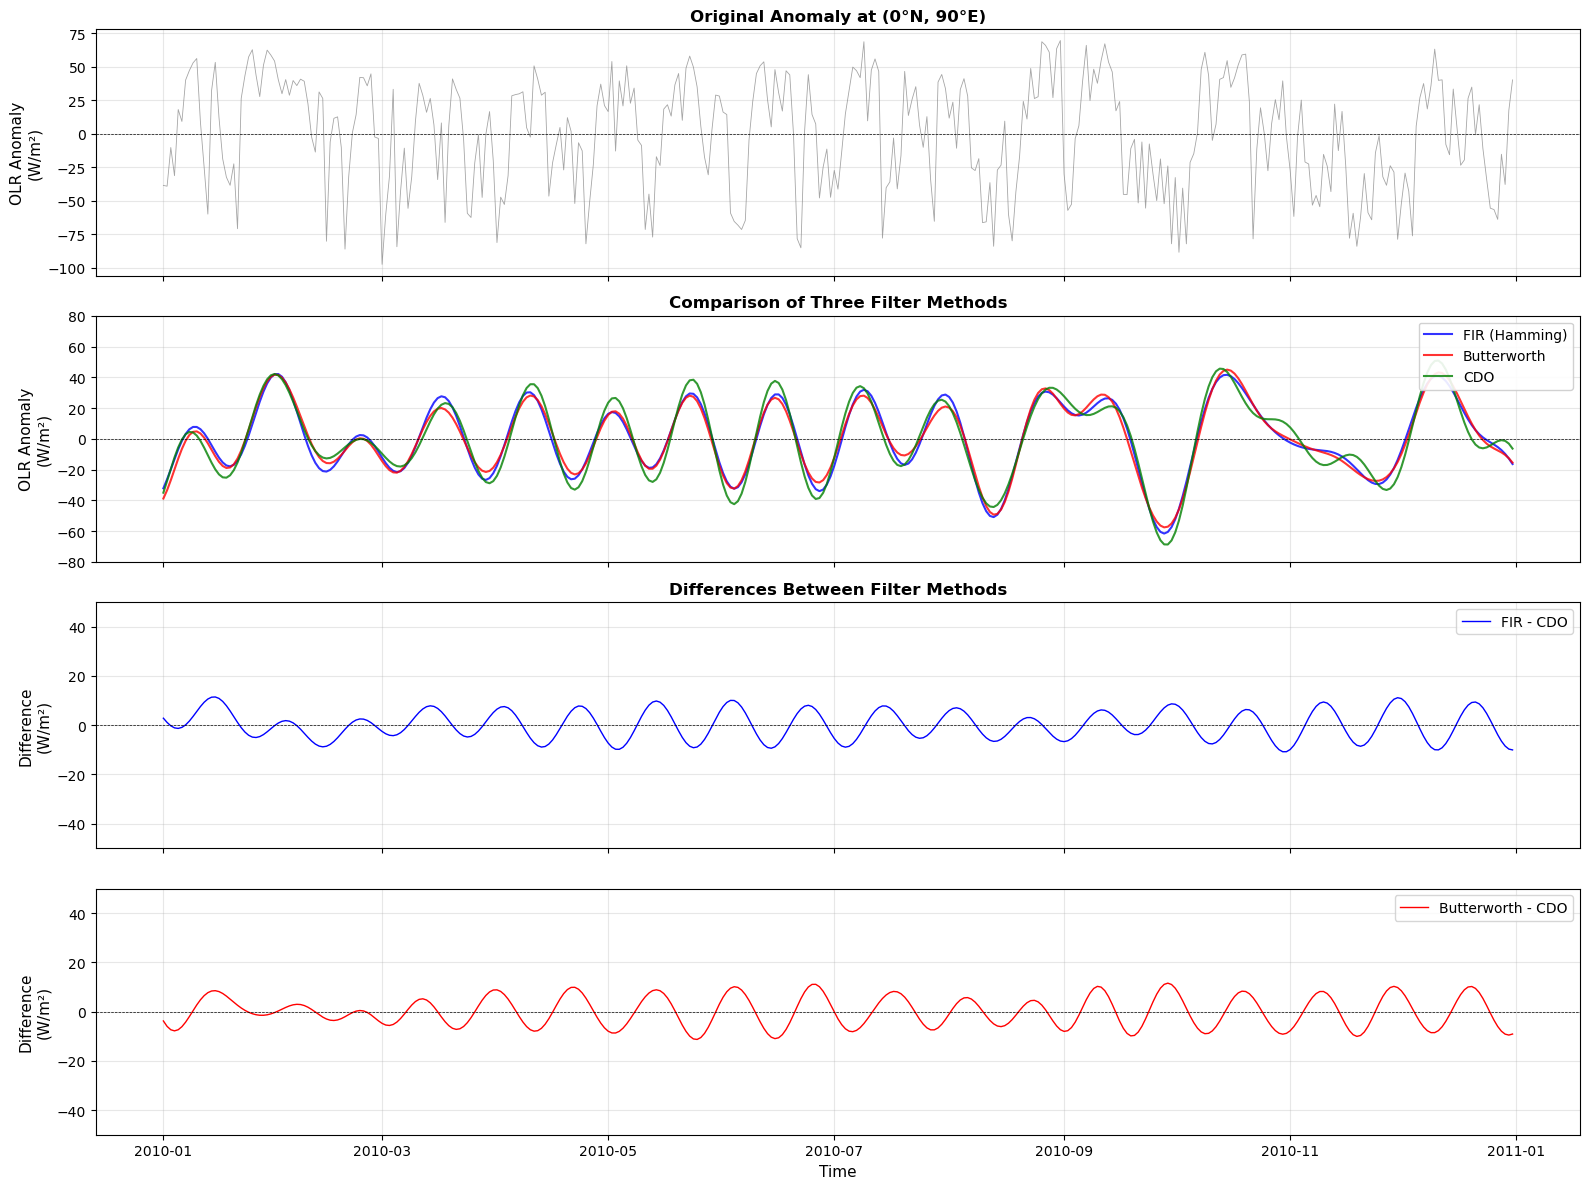


Three-Method Comparison Statistics at (0°N, 90°E)
Method               Range (W/m²)              Mean         Std Dev     
--------------------------------------------------------------------------------
Original             -130.62 to 94.48              0.0059    41.2344
FIR (Hamming)        -74.48 to 65.50               0.0043    22.2185
Butterworth          -78.71 to 65.69              -0.0186    22.8500
CDO                  -83.27 to 78.07              -0.0000    24.1123

Comparison           RMSE         Correlation  Max |Diff|  
--------------------------------------------------------------------------------
FIR vs CDO           5.5091       0.975022     17.9546     
Butterworth vs CDO   5.0423       0.978373     38.4900     
FIR vs Butterworth   4.0260       0.984430     45.3625     



In [76]:
# Compare all three filter methods in one figure
compare_three_filters(olr_anom, olr_filtered, olr_filtered_butter, olr_cdo_filtered, 
                     lat=0, lon=90, time_slice='2010')

In [77]:
# ── 调用 geocat_fourier_bandpass 进行 20–80 天带通滤波 ──────────────────
olr_filtered_geocat = geocat_fourier_bandpass(
    olr_anom_clean,
    low_period=80,
    high_period=20,
)

print(f"Shape    : {olr_filtered_geocat.shape}")
print(f"NaN count: {int(olr_filtered_geocat.isnull().sum())}")
olr_filtered_geocat


Applying geocat.comp.fourier_band_pass (20–80 day)  [serial]
  cutoff_frequency_low  = 1/80  = 0.01250 cycle/day
  cutoff_frequency_high = 1/20 = 0.05000 cycle/day
  Completed in 6.904 s
Shape    : (13880, 73, 144)
NaN count: 0
  Completed in 6.904 s
Shape    : (13880, 73, 144)
NaN count: 0


<xarray.DataArray 'olr_anomaly_geocat_fourier' (time: 13880, lat: 73, lon: 144)> Size: 584MB
array([[[-1.6398649 , -1.6398649 , -1.6398649 , ..., -1.6398649 ,
         -1.6398649 , -1.6398649 ],
        [-1.8821785 , -1.662088  , -1.9143991 , ...,  1.5022402 ,
          0.44022846, -2.6295536 ],
        [ 0.5983853 , -3.70955   , -2.3759513 , ...,  9.492017  ,
          9.491823  ,  4.72754   ],
        ...,
        [ 4.4373612 ,  4.4843006 ,  4.5284114 , ...,  3.9028943 ,
          3.9579144 ,  3.9960718 ],
        [ 5.405535  ,  5.4324265 ,  5.4813647 , ...,  4.2255673 ,
          4.273024  ,  4.310321  ],
        [ 4.906179  ,  4.906179  ,  4.906179  , ...,  4.906179  ,
          4.906179  ,  4.906179  ]],

       [[-3.1590996 , -3.1590996 , -3.1590996 , ..., -3.1590996 ,
         -3.1590996 , -3.1590996 ],
        [-3.666552  , -3.376418  , -3.7281654 , ..., -0.32778218,
         -1.3292726 , -4.2486477 ],
        [-1.6931763 , -5.2928376 , -4.7096763 , ...,  7.8733134 ,
          7.8982396 ,  3.0929403 ],
...
        [ 3.1049464 ,  3.2139654 ,  3.3197994 , ...,  2.3662114 ,
          2.4727342 ,  2.571431  ],
        [ 4.124763  ,  4.1744585 ,  4.2433634 , ...,  2.8068855 ,
          2.8793697 ,  2.9372866 ],
        [ 3.1322637 ,  3.1322637 ,  3.1322637 , ...,  3.1322637 ,
          3.1322637 ,  3.1322637 ]],

       [[ 0.07179768,  0.07179768,  0.07179768, ...,  0.07179768,
          0.07179768,  0.07179768],
        [ 0.03460753,  0.18401237,  0.03824664, ...,  3.325828  ,
          2.234097  , -0.8699189 ],
        [ 2.8382792 , -1.8913168 ,  0.05969816, ..., 10.7799015 ,
         10.756871  ,  6.27097   ],
        ...,
        [ 3.8485124 ,  3.9283    ,  4.005262  , ...,  3.209162  ,
          3.2913222 ,  3.3612895 ],
        [ 4.8720975 ,  4.911144  ,  4.971229  , ...,  3.604554  ,
          3.6656907 ,  3.7143364 ],
        [ 4.10547   ,  4.10547   ,  4.10547   , ...,  4.10547   ,
          4.10547   ,  4.10547   ]]], dtype=float32)
Coordinates:
  * lon      (lon) float32 576B 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * lat      (lat) float32 292B 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * time     (time) datetime64[ns] 111kB 1979-01-01 1979-01-02 ... 2016-12-31
Attributes:
    long_name:  20-80 day fourier_band_pass (geocat)

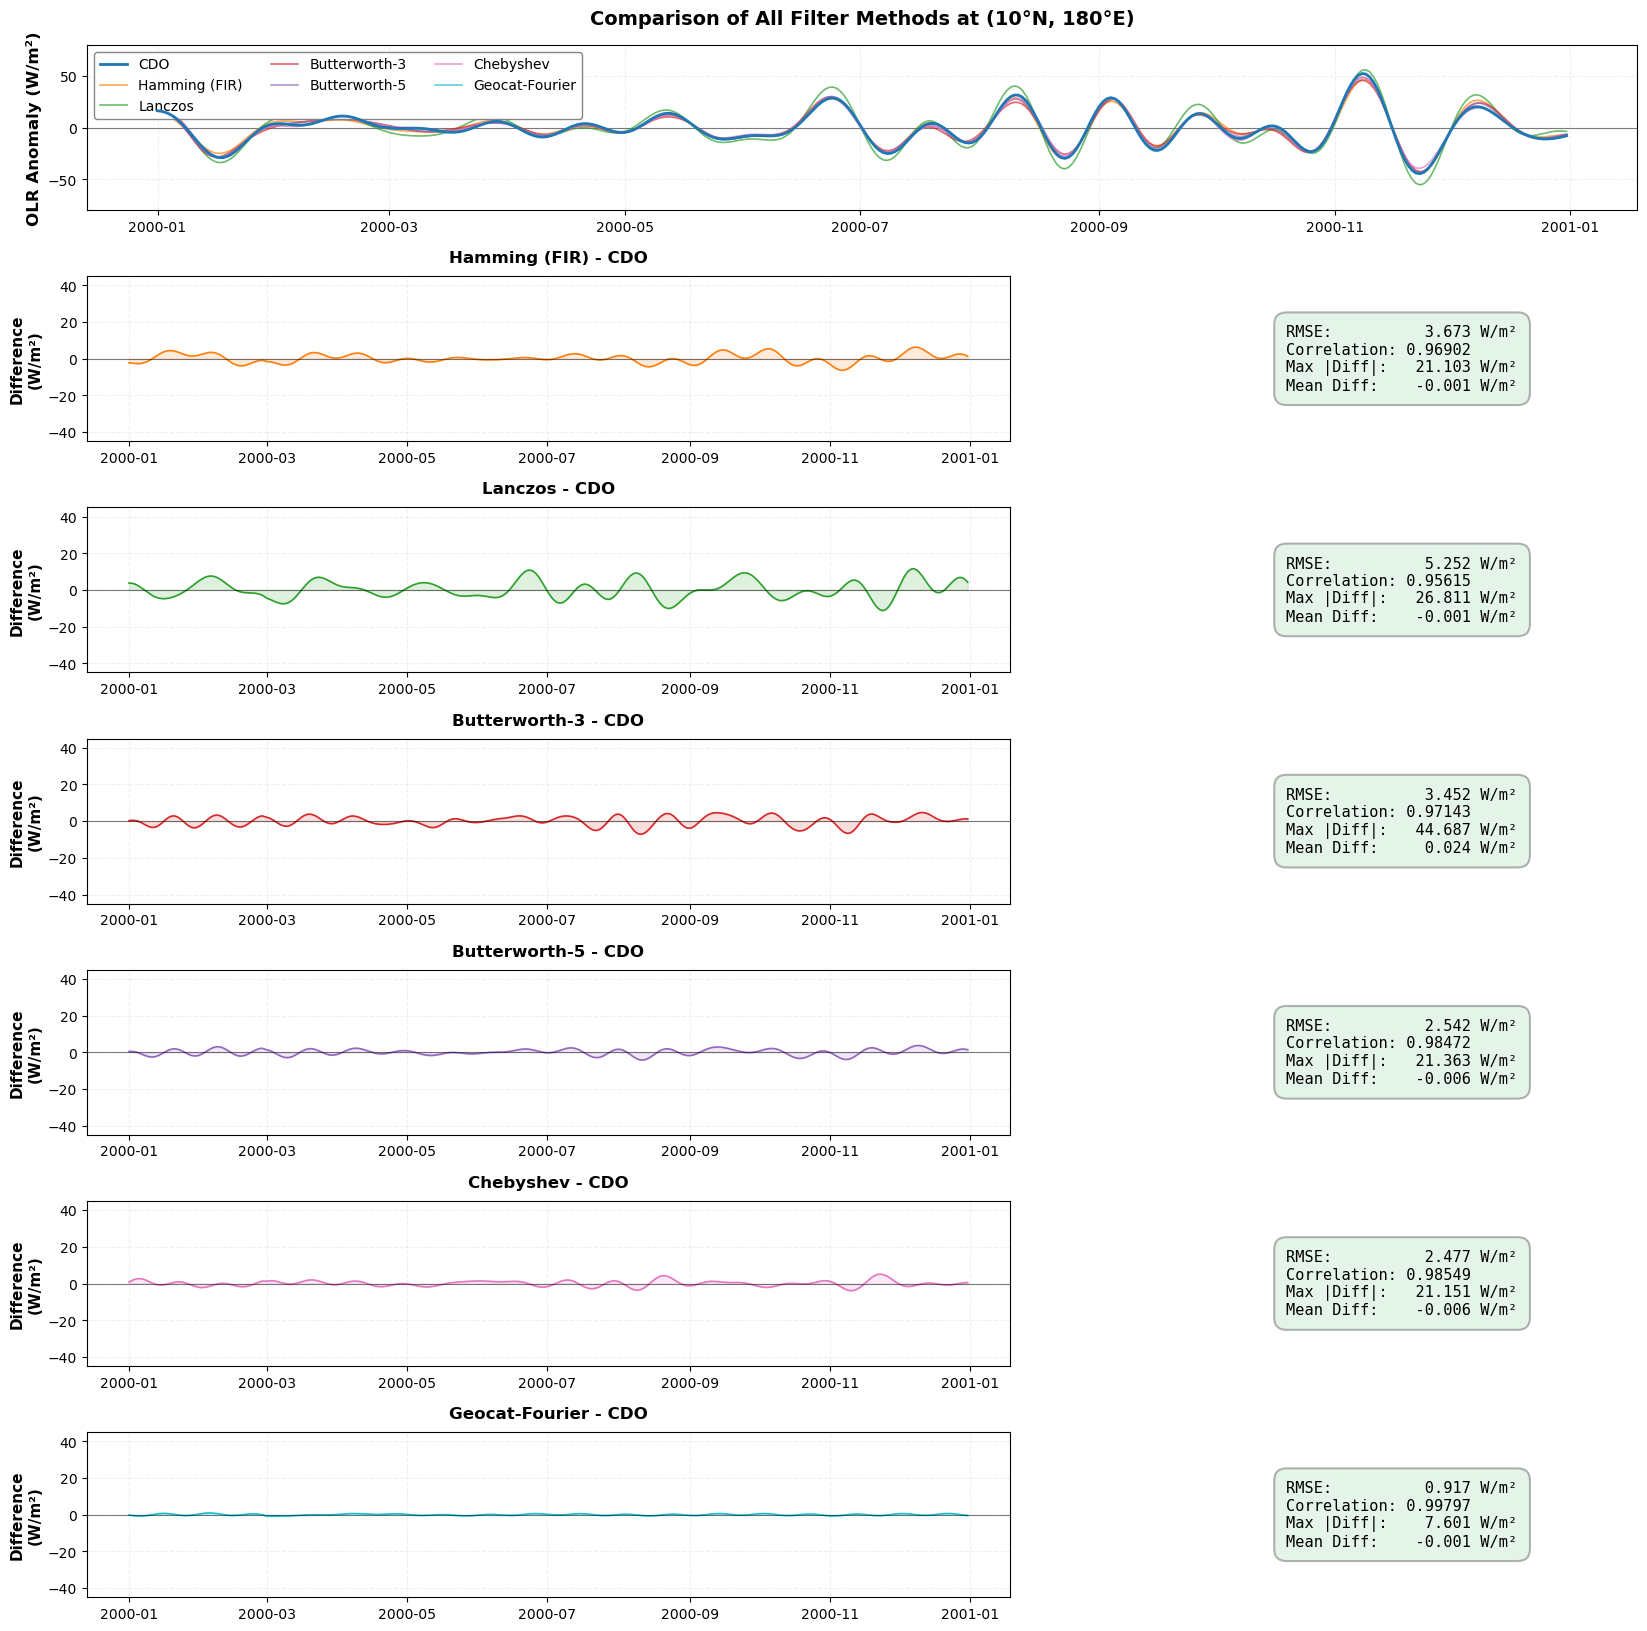


Comprehensive Filter Comparison at (10°N, 180°E)
Filter               Range (W/m²)              Mean         Std Dev      Valid Data  
----------------------------------------------------------------------------------------------------
CDO                  -53.14 to 52.31              -0.0000    14.4126    100.0%
Hamming (FIR)        -49.22 to 47.03              -0.0009    13.0598    100.0%
Lanczos              -65.48 to 58.15              -0.0010    16.9056    100.0%
Butterworth-3        -52.15 to 62.19               0.0237    13.5412    100.0%
Butterworth-5        -52.13 to 49.66              -0.0061    13.7900    100.0%
Chebyshev            -51.33 to 49.08              -0.0060    13.8146    100.0%
Geocat-Fourier       -52.52 to 52.22              -0.0007    14.3961    100.0%

Comparison vs CDO    RMSE         Correlation    Max |Diff|   Mean Diff    Quality   
----------------------------------------------------------------------------------------------------
Hamming (FIR)        3

In [78]:
# ── 与其他所有方法统一比较 ─────────────────────────────────────────────
# 将 geocat Fourier 滤波加入已有滤波字典，以 CDO 为参考基准

all_filters_with_geocat = {
    'CDO':            olr_cdo_filtered,
    'Hamming (FIR)':  olr_filtered_hamming,
    'Lanczos':        olr_filtered_lanczos,
    'Butterworth-3':  olr_filtered_butter3,
    'Butterworth-5':  olr_filtered_butter5,
    'Chebyshev':      olr_filtered_cheby,
    'Geocat-Fourier': olr_filtered_geocat,   # ← 新增
}

compare_all_filters(
    olr_anom,
    all_filters_with_geocat,
    lat=10, lon=180,
    time_slice='2000',
    reference='CDO'
)


In [79]:
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 各滤波方法的运行时间基准测试 ──────────────────────────────────────────
# 每种方法重复 N_REPEAT 次，取平均时间，减少随机波动

N_REPEAT = 3

benchmarks = {}

def bench(name, func, *args, **kwargs):
    times = []
    for _ in range(N_REPEAT):
        t0 = time.perf_counter()
        func(*args, **kwargs)
        times.append(time.perf_counter() - t0)
    avg = np.mean(times)
    benchmarks[name] = avg
    print(f"  {name:<20s}: {avg:.3f} s  (avg over {N_REPEAT} runs)")

print(f"Benchmarking all band-pass filters (20–80 day), {N_REPEAT} runs each...\n")

# 1. Hamming (FIR) via apply_intraseasonal_filter
bench("Hamming (FIR)",
      apply_intraseasonal_filter,
      olr_anom_clean, low_period=80, high_period=20)

# 2. Lanczos
bench("Lanczos",
      apply_filter_to_data,
      olr_anom_clean, lanczos_filter, 'Lanczos',
      low_period=80, high_period=20, window=121)

# 3. Butterworth-3
bench("Butterworth-3",
      apply_filter_to_data,
      olr_anom_clean, butterworth_filter, 'Butterworth-3',
      low_period=80, high_period=20, order=3)

# 4. Butterworth-5
bench("Butterworth-5",
      apply_filter_to_data,
      olr_anom_clean, butterworth_filter, 'Butterworth-5',
      low_period=80, high_period=20, order=5)

# 5. Butterworth-8
bench("Butterworth-8",
      apply_filter_to_data,
      olr_anom_clean, butterworth_filter, 'Butterworth-8',
      low_period=80, high_period=20, order=8)

# 6. Chebyshev
bench("Chebyshev",
      apply_filter_to_data,
      olr_anom_clean, chebyshev_filter, 'Chebyshev',
      low_period=80, high_period=20, order=5, ripple=0.5)

# 7. Geocat Fourier
bench("Geocat-Fourier",
      geocat_fourier_bandpass,
      olr_anom_clean, low_period=80, high_period=20)

print(f"\nDone. Fastest → Slowest:")
for name, t in sorted(benchmarks.items(), key=lambda x: x[1]):
    print(f"  {name:<20s}: {t:.3f} s")


Benchmarking all band-pass filters (20–80 day), 3 runs each...

Applying Hamming (FIR) 20-80 day  [serial]
  Frequency range: 0.01250 to 0.05000 cycles/day
  Completed in 14.079 s
Applying Hamming (FIR) 20-80 day  [serial]
  Frequency range: 0.01250 to 0.05000 cycles/day
  Completed in 14.079 s
Applying Hamming (FIR) 20-80 day  [serial]
  Frequency range: 0.01250 to 0.05000 cycles/day
  Completed in 13.783 s
Applying Hamming (FIR) 20-80 day  [serial]
  Frequency range: 0.01250 to 0.05000 cycles/day
  Completed in 13.783 s
Applying Hamming (FIR) 20-80 day  [serial]
  Frequency range: 0.01250 to 0.05000 cycles/day
  Completed in 13.668 s
  Hamming (FIR)       : 13.874 s  (avg over 3 runs)
Applying Lanczos  [serial]...
  Completed in 13.668 s
  Hamming (FIR)       : 13.874 s  (avg over 3 runs)
Applying Lanczos  [serial]...
  Completed in 10.289 s
Applying Lanczos  [serial]...
  Completed in 10.289 s
Applying Lanczos  [serial]...
  Completed in 10.268 s
Applying Lanczos  [serial]...
  Comp

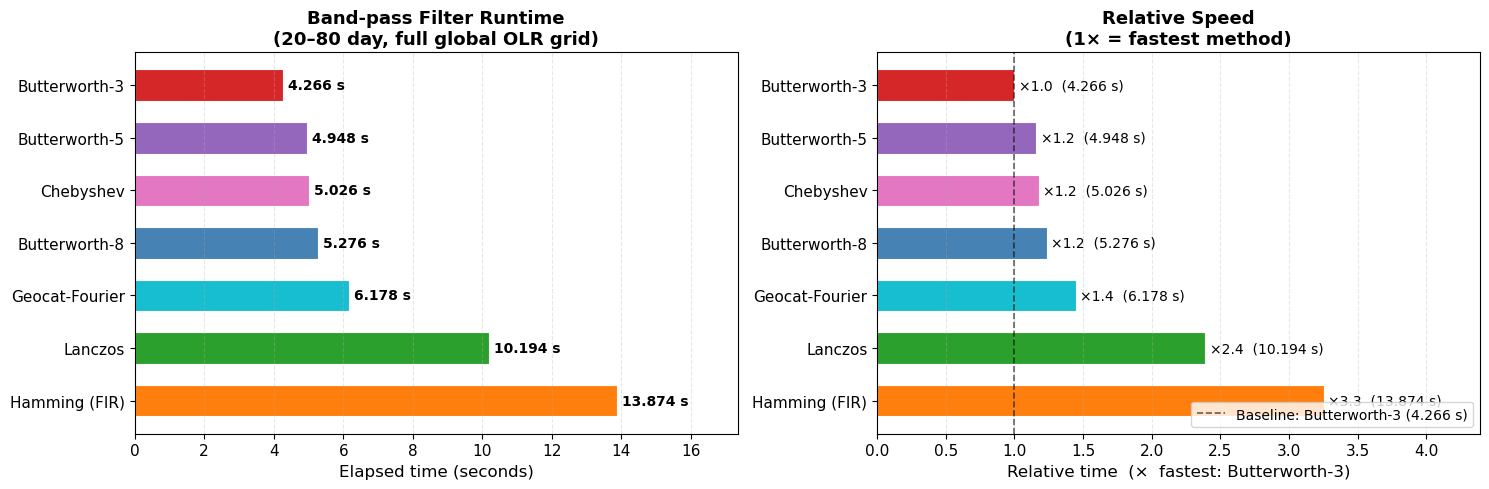

In [80]:
# ── 绘制运行速度对比图 ────────────────────────────────────────────────────

color_palette = {
    'Hamming (FIR)':  '#ff7f0e',
    'Lanczos':        '#2ca02c',
    'Butterworth-3':  '#d62728',
    'Butterworth-5':  '#9467bd',
    'Chebyshev':      '#e377c2',
    'Geocat-Fourier': '#17becf',
}

# 按运行时间从快到慢排序
names_sorted = sorted(benchmarks, key=lambda x: benchmarks[x])
times_sorted = [benchmarks[n] for n in names_sorted]
colors_sorted = [color_palette.get(n, 'steelblue') for n in names_sorted]
fastest = times_sorted[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── 左图：绝对时间横向条形图 ──────────────────────────────────────────────
bars = axes[0].barh(names_sorted, times_sorted, color=colors_sorted,
                    edgecolor='white', linewidth=0.8, height=0.6)
for bar, t in zip(bars, times_sorted):
    axes[0].text(t + max(times_sorted) * 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{t:.3f} s', va='center', ha='left', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Elapsed time (seconds)', fontsize=12)
axes[0].set_title('Band-pass Filter Runtime\n(20–80 day, full global OLR grid)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlim(0, max(times_sorted) * 1.25)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].invert_yaxis()
axes[0].tick_params(labelsize=11)

# ── 右图：相对速度（归一化为最快方法的倍数）────────────────────────────────
slowdown = [t / fastest for t in times_sorted]
bars2 = axes[1].barh(names_sorted, slowdown, color=colors_sorted,
                     edgecolor='white', linewidth=0.8, height=0.6)
for bar, sd, t in zip(bars2, slowdown, times_sorted):
    label = f'×{sd:.1f}  ({t:.3f} s)'
    axes[1].text(sd + max(slowdown) * 0.01, bar.get_y() + bar.get_height() / 2,
                 label, va='center', ha='left', fontsize=10)
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.6,
                label=f'Baseline: {names_sorted[0]} ({fastest:.3f} s)')
axes[1].set_xlabel(f'Relative time  (×  fastest: {names_sorted[0]})', fontsize=12)
axes[1].set_title('Relative Speed\n(1× = fastest method)', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, max(slowdown) * 1.35)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].legend(fontsize=10, loc='lower right')
axes[1].invert_yaxis()
axes[1].tick_params(labelsize=11)

plt.tight_layout()

plt.show()

